# New MeSH medical terms as a held-out check set: `data.py` demo

This notebook walks through **`data.py`**, the script that packages the *held-out MeSH confirmation population* into the pipeline's `exp_sel_data_out` schema (`full_data_out.json`).

**What the population is.** It has 191 new biomedical concepts. Each is a MeSH descriptor established between 2006 and 2016 (the plan widened this to 2004–2005 and 2017–2018). Every concept passed three filters:
1. **A Nentidis-style provenance filter.** It drops descriptors that were parenthetical-prior-year, promoted or renamed.
2. **A free PubMed `[tiab]` novelty pre-screen.**
3. **The main corpus's final emergence rule on OpenAlex counts:**
   - `F`, the first year with at least 5 papers, falls in 2005–2016;
   - 20–300 papers fall in `F..F+2`;
   - at most 8,000 papers appear over 2000–2024.

The population is an **independent check set** for the emerging-concept study ("occupancy is not integration"). Concept identity and synonyms come only from MeSH preferred-concept terms, not from the text-mining pipeline under test.

**What `data.py` does.** It reads two source tables and turns each row into one `{input, output, metadata_*}` example:

| dataset | 1 example per | `input` | `output` |
|---|---|---|---|
| `heldout_mesh_concepts` | concept | concept identity (JSON): descriptor UI, preferred term, surface forms, acronyms, tree numbers, `F`, origin field/subfield | yearly incidence 2000–2024 and retrieval counts (JSON) |
| `mesh_synonym_pairs` | term pair | `{"term_a","term_b"}` | `"1"` synonym/acronym, `"0"` hard negative |

It also writes `mini_works.json` and `preview_works.json`. These are small previews of the concept–work rows in `works/works_part_XX.jsonl.gz`.

**Demo data.** The notebook does not need the full source tables (about 10 MB, plus about 73 MB of gzipped works). `mini_demo_data.json` is a curated subset:
- **60 of the 191 concepts**, stratified by MeSH branch group × `final_rule_basis`;
- **30 of the 23,097 synonym / hard-negative pairs**, covering every `pair_type` × leakage-fold cell;
- **the first 10 concept–work rows** of `works_part_01.jsonl.gz`. These are exactly the rows the original `works_sample(10)` reads.

The script's code is unchanged except where it reads these tables. The notebook takes them from the loaded `data` dict instead of from `temp/datasets/`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# data.py itself only uses the Python standard library (gzip, json, sys, pathlib) -> nothing extra to install.
# numpy, pandas, matplotlib are used only by the summary/visualisation cells — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

In [2]:
# --- original import block of data.py ---
from __future__ import annotations

import gzip
import json
import sys
from pathlib import Path

# --- additional imports for the notebook (summary + plots) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-1/dataset-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print({"heldout_mesh_concepts": len(data["heldout_mesh_concepts"]),
       "mesh_synonym_pairs": len(data["mesh_synonym_pairs"]["pairs"]),
       "works_rows": len(data["works_rows"])})

Curated demo subset of the held-out MeSH population source tables read by data.py (temp/datasets/heldout_mesh_concepts.json, temp/datasets/mesh_synonym_pairs.json, works/works_part_01.jsonl.gz): 60 of 191 concepts stratified by MeSH branch group x final_rule_basis, 30 of 23097 synonym/hard-negative pairs covering every pair_type x fold cell, and the first 10 concept-work rows.
{'heldout_mesh_concepts': 60, 'mesh_synonym_pairs': 30, 'works_rows': 10}


## Configuration

`data.py` has no model hyper-parameters. Its only knobs are how many source rows it packages and how large the mini and preview files are. The values below cover the **whole demo subset** and take a few seconds:

| setting | demo subset | original |
|---|---|---|
| concepts | 60 | all 191 |
| pairs | 30 | all 23,097 |
| work rows | 10 | 10 |

To reproduce the original scale, run `uv run data.py` in the artifact's own folder, which has the full source tables.

In [5]:
N_CONCEPTS = 60        # concepts to package (demo subset has 60; original: all 191 rows of heldout_mesh_concepts.json)
N_PAIRS = 30           # synonym / hard-negative pairs to package (demo subset has 30; original: all 23,097 pairs)
N_WORKS_SAMPLE = 10    # concept-work rows sampled for preview_works.json (original: works_sample(10))
MINI_N = 3             # rows kept in mini_works.json (original: wex[:3])
TRUNCATE_N = 200       # max string length in preview_works.json (original: truncate(..., n=200))

## Paths and dataset list

In the original script, `ROOT` is the script's own folder and `SRC = ROOT/temp/datasets`. A notebook has no `__file__`, so `ROOT` is the current working directory here, and outputs such as `full_data_out.json` are written there. The source tables come from `data`, not from `SRC`.

In [6]:
ROOT = Path.cwd()                     # original: Path(__file__).resolve().parent
SRC = ROOT / "temp" / "datasets"      # kept for reference; in the notebook the source tables come from `data`
DATASETS = ["heldout_mesh_concepts", "mesh_synonym_pairs"]

## Helpers: compact JSON and flat metadata

The `exp_sel_data_out` schema requires `input` and `output` to be **strings**, and metadata to be **flat** `metadata_*` fields.
- `dumps` serialises with compact separators.
- `flat_metadata` lifts one level of nesting. For example, `{"pubmed_prescreen": {"F_pubmed": ...}}` becomes `metadata_pubmed_prescreen_F_pubmed`.

In [7]:
def dumps(o) -> str:
    return json.dumps(o, ensure_ascii=False, separators=(",", ":"))


def flat_metadata(meta: dict, prefix: str = "metadata_") -> dict:
    """Flatten one nesting level into metadata_<key> / metadata_<key>_<sub> fields (schema wants flat fields)."""
    out = {}
    for k, v in meta.items():
        if isinstance(v, dict):
            for k2, v2 in v.items():
                out[f"{prefix}{k}_{k2}"] = v2
        else:
            out[f"{prefix}{k}"] = v
    return out

## Dataset 1: `heldout_mesh_concepts` (one example per concept)

Each source row has three parts:
- **`input`**: the MeSH identity of the concept. It gives the descriptor UI and preferred term, `surface_forms` (the preferred-concept terms used for text matching), `excluded_forms`, `acronyms`, tree numbers, `DateEstablished` and provenance class. It also gives the emergence year `F`, `early_count_F_to_F2`, and the OpenAlex `origin_field` / `origin_subfield`.
- **`output`**: yearly incidence for 2000–2024, in four series:
  - `yearly_counts_textmatch`, over locally verified works;
  - `yearly_counts_mesh_indexed`;
  - `yearly_counts_nonpubmed_openalex_groupby`;
  - `yearly_counts_final_rule`.

  It also has `final_rule_basis`, which says which retrieval route the final rule relied on, and retrieval counts.
- **`metadata`**: stratum, sample rank, seed, `retrieval_complete`, `rule_parity`, and so on.

Each row becomes one example, with `input` and `output` stored as JSON strings plus a few convenience metadata fields.

*Change from the original:* `rows` comes from `data["heldout_mesh_concepts"]` instead of `SRC/heldout_mesh_concepts.json`, and is cut to `N_CONCEPTS`.

In [8]:
def concepts() -> list[dict]:
    rows = data["heldout_mesh_concepts"][:N_CONCEPTS]   # original: json.loads((SRC / "heldout_mesh_concepts.json").read_text())
    ex = []
    for i, c in enumerate(rows):
        e = {"input": dumps(c["input"]), "output": dumps(c["output"]), "metadata_fold": c["metadata_fold"]}
        e.update(flat_metadata(c["metadata"]))
        e.update({"metadata_row_index": i, "metadata_concept_id": c["input"]["concept_id"],
                  "metadata_preferred_term": c["input"]["preferred_term"], "metadata_F": c["input"]["F"],
                  "metadata_task_type": "emergence_trajectory",
                  "metadata_input_fields": sorted(c["input"]), "metadata_output_fields": sorted(c["output"])})
        ex.append(e)
    return ex

## Dataset 2: `mesh_synonym_pairs` (one example per term pair)

The pairs come from MeSH (desc2017) over all 3,430 provenance-filtered descriptors from 2006–2016.
- **Positives (label `1`):** `synonym` and `acronym_expansion` pairs.
- **Hard negatives (label `0`):** a `sibling_descriptor`, or a narrower (`nrw`), broader (`brd`) or related (`rel`) non-preferred concept.

The derived `metadata_fold` guards against leakage:
- `heldout_mesh`: the pair touches one of the 191 held-out concepts;
- `working_list`: the pair touches the wider candidate list;
- `train_eligible`: the pair is safe for training a synonym or grounding model.

*Change from the original:* `d` comes from `data["mesh_synonym_pairs"]` instead of `SRC/mesh_synonym_pairs.json`, and its `pairs` list is cut to `N_PAIRS`. The demo subset contains pairs from all three folds, so every branch of the fold expression runs.

In [9]:
def pairs() -> list[dict]:
    d = data["mesh_synonym_pairs"]   # original: json.loads((SRC / "mesh_synonym_pairs.json").read_text())
    ex = []
    for i, p in enumerate(d["pairs"][:N_PAIRS]):   # original: enumerate(d["pairs"])
        fold = "heldout_mesh" if p["in_heldout_population"] else ("working_list" if p["in_working_list"] else "train_eligible")
        ex.append({"input": dumps({"term_a": p["term_a"], "term_b": p["term_b"]}), "output": str(p["label"]),
                   "metadata_fold": fold, "metadata_pair_type": p["pair_type"],
                   "metadata_descriptor_ui": p["descriptor_ui"], "metadata_descriptor_ui_b": p["descriptor_ui_b"],
                   "metadata_orig_a": p["orig_a"], "metadata_orig_b": p["orig_b"],
                   "metadata_in_heldout_population": p["in_heldout_population"],
                   "metadata_in_working_list": p["in_working_list"], "metadata_task_type": "classification",
                   "metadata_n_classes": 2, "metadata_row_index": i})
    return ex

## Sample of concept–work rows, and string truncation for previews

The 122,645 concept–work rows ship separately as gzip JSONL parts, one row per (concept, work) pair. `works_sample` turns the first `n` rows into schema examples for `mini_works.json` and `preview_works.json`:
- **`input`**: the work record, in the compact main-corpus schema;
- **`output`**: how the work was assigned to the concept: `match_route`, `verified_text_match`, `match_field`, `matched_forms`, and the descriptor-indexing flags.

For counts comparable with the main corpus, use only rows with `verified_text_match=true`.

`truncate` shortens every string to `n` characters so the preview file stays small.

*Change from the original:* rows come from `data["works_rows"]` instead of `gzip.open(ROOT/"works"/"works_part_01.jsonl.gz")`. They are the first 10 decoded lines of that same file.

In [10]:
def works_sample(n: int) -> list[dict]:
    """First n concept-work rows (works/works_part_01.jsonl.gz) as schema examples, for mini/preview_works.json.
    The works themselves ship as gzip JSONL parts (one row per (concept, work)), not in full_data_out.json."""
    assign = ("concept_id", "match_route", "verified_text_match", "match_field", "matched_forms",
              "descriptor_indexed_openalex", "descriptor_indexed_pubmed")
    ex = []
    # original: with gzip.open(ROOT / "works" / "works_part_01.jsonl.gz", "rt", encoding="utf-8") as fh:
    #               for line in fh:
    #                   w = json.loads(line)
    for w in data["works_rows"]:
        ex.append({"input": dumps({k: v for k, v in w.items() if k not in assign and k != "metadata_fold"}),
                   "output": dumps({k: w[k] for k in assign}), "metadata_fold": w["metadata_fold"],
                   "metadata_concept_id": w["concept_id"], "metadata_work_id": w["work_id"],
                   "metadata_publication_year": w["publication_year"], "metadata_row_index": len(ex)})
        if len(ex) >= n:
            break
    return ex


def truncate(o, n: int = 200):
    if isinstance(o, str):
        return o[:n]
    if isinstance(o, list):
        return [truncate(x, n) for x in o]
    if isinstance(o, dict):
        return {k: truncate(v, n) for k, v in o.items()}
    return o


BUILDERS = {"heldout_mesh_concepts": concepts, "mesh_synonym_pairs": pairs}

## `main()`: build and write `full_data_out.json`

This is the original flow:
1. Check the inputs.
2. Run each builder.
3. Write `full_data_out.json` in the `{metadata, datasets:[{dataset, examples}]}` layout.
4. If work rows are available, write `mini_works.json` and `preview_works.json`.

*Changes from the original:*
- The missing-input check looks for keys of `data` instead of files.
- The works check tests `data["works_rows"]` instead of the gzip file.
- The config variables replace the literal `10`, `3` and `200`.
- `main()` returns `out` so the cells below can inspect it.

In [11]:
def main() -> None:
    missing = [f for f in ("heldout_mesh_concepts", "mesh_synonym_pairs") if f not in data]   # original: files missing from SRC
    if missing:
        sys.exit(f"missing inputs in {SRC}: {missing} (run scripts/s10_export_datasets.py after build_population.py)")
    out = {"metadata": {"source": "held-out MeSH population (metadata_fold heldout_mesh); NLM MeSH + PubMed + OpenAlex (CC0)",
                        "description": "See README.md and provenance.md. input/output are JSON strings unless noted.",
                        "datasets": DATASETS},
           "datasets": []}
    for n in DATASETS:
        ex = BUILDERS[n]()
        out["datasets"].append({"dataset": n, "examples": ex})
        print(f"{n}: {len(ex)} examples")
    target = ROOT / "full_data_out.json"
    target.write_text(json.dumps(out, ensure_ascii=False))
    print(f"wrote {target.name} ({target.stat().st_size / 1e6:.1f} MB)")
    if data.get("works_rows"):   # original: (ROOT / "works" / "works_part_01.jsonl.gz").exists()
        meta = {"description": "first concept-work rows of works/works_part_XX.jsonl.gz (heldout_mesh_works)"}
        wex = works_sample(N_WORKS_SAMPLE)   # original: works_sample(10)
        (ROOT / "mini_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": wex[:MINI_N]}]}, indent=1))
        (ROOT / "preview_works.json").write_text(json.dumps(
            {"metadata": meta, "datasets": [{"dataset": "heldout_mesh_works", "examples": truncate(wex, TRUNCATE_N)}]}, indent=1))
        print("wrote mini_works.json, preview_works.json")
    return out   # notebook addition: hand the result to the summary cells

In [12]:
out = main()

heldout_mesh_concepts: 60 examples
mesh_synonym_pairs: 30 examples
wrote full_data_out.json (0.8 MB)


wrote mini_works.json, preview_works.json


## Inspect the packaged examples

This shows one example from each dataset. `input` and `output` are JSON strings, so they are decoded before printing.

In [13]:
ex_c = out["datasets"][0]["examples"][0]
print("== heldout_mesh_concepts example ==")
print(json.dumps(json.loads(ex_c["input"]), indent=1)[:1200])
o = json.loads(ex_c["output"])
print("final_rule_basis:", o["final_rule_basis"], "| total_final_rule_2000_2024:", o["total_final_rule_2000_2024"])
print({k: v for k, v in ex_c.items() if k.startswith("metadata_") and not isinstance(v, list)})

ex_p = out["datasets"][1]["examples"][0]
print("\n== mesh_synonym_pairs example ==")
print(ex_p["input"], "->", ex_p["output"], "|", ex_p["metadata_pair_type"], "|", ex_p["metadata_fold"])

w = json.loads((ROOT / "mini_works.json").read_text())["datasets"][0]["examples"][0]
print("\n== mini_works.json example (assignment part) ==")
print(w["output"])

== heldout_mesh_concepts example ==
{
 "concept_id": "mesh:D000068099",
 "descriptor_ui": "D000068099",
 "preferred_term": "Trauma and Stressor Related Disorders",
 "surface_forms": [
  "Trauma and Stressor Related Disorders"
 ],
 "excluded_forms": [],
 "acronyms": [],
 "narrower_concept_terms": [],
 "tree_numbers": [
  "F03.950"
 ],
 "tree_branch_primary": "F",
 "date_established": "2016-01-01",
 "mesh_year_established": 2016,
 "history_note": "2016",
 "public_mesh_note": "2016",
 "previous_indexing": [],
 "provenance_class": "NO_PRIOR",
 "chemical_flag": false,
 "F": 2013,
 "early_count_F_to_F2": 65,
 "origin_field": 32,
 "origin_subfield": 3203,
 "pubmed_query": "(\"Trauma and Stressor Related Disorders\"[tiab])"
}
final_rule_basis: verified_union | total_final_rule_2000_2024: 347
{'metadata_fold': 'heldout_mesh', 'metadata_stratum': 'F+H-N|T2_mid|2011-2016', 'metadata_branch_group': 'F+H-N', 'metadata_volume_tercile': 'T2_mid', 'metadata_establishment_period': '2011-2016', 'metadat

## Results summary and visualisation

These cells decode the `output` JSON of every packaged concept and show four things:
1. **Summary tables.** Concepts per MeSH branch group (median emergence year `F`, early count, total), concepts per final-rule basis, and pairs by type × label and fold.
2. **Incidence aligned on the emergence year `F`.** Median yearly final-rule counts per branch group: the trajectory an emergence study models.
3. **Text match vs MeSH indexing.** Text mentions show up years before MeSH indexing catches up, which is why the population is matched on text.
4. **The synonym-pair label mix.**

In [14]:
years = [str(y) for y in range(2000, 2025)]
recs = []
for e in out["datasets"][0]["examples"]:
    i, o = json.loads(e["input"]), json.loads(e["output"])
    recs.append({"term": i["preferred_term"], "branch": e["metadata_branch_group"], "F": i["F"],
                 "basis": o["final_rule_basis"], "early_F_F2": i["early_count_F_to_F2"],
                 "total_final": o["total_final_rule_2000_2024"], "year_est": i["mesh_year_established"],
                 "final": np.array([o["yearly_counts_final_rule"][y] for y in years], float),
                 "text": np.array([o["yearly_counts_textmatch"][y] for y in years], float),
                 "mesh": np.array([o["yearly_counts_mesh_indexed"][y] for y in years], float)})
df = pd.DataFrame(recs)
pd.set_option("display.width", 160)
print(df.groupby("branch").agg(n=("term", "size"), median_F=("F", "median"),
                               median_early_F_F2=("early_F_F2", "median"), median_total=("total_final", "median")))
print()
print(df["basis"].value_counts().rename("concepts by final_rule_basis"))
print()
pdf = pd.DataFrame(out["datasets"][1]["examples"])
print(pd.crosstab(pdf["metadata_pair_type"], pdf["output"]).rename(columns={"0": "label 0 (hard neg)", "1": "label 1 (synonym)"}))
print()
print(pd.crosstab(pdf["metadata_pair_type"], pdf["metadata_fold"]))
print()
print(df.sort_values("total_final", ascending=False)[["term", "branch", "F", "year_est", "early_F_F2", "total_final", "basis"]].head(10).to_string(index=False))

         n  median_F  median_early_F_F2  median_total
branch                                               
A+B     11    2009.0               29.0         419.0
C        8    2008.0               29.0         632.5
D       14    2008.5               32.0         553.5
E       13    2009.0               30.0         887.0
F+H-N    8    2007.0               27.0         563.0
G        6    2006.0               27.0         435.5

basis
pubmed_route_verified+nonpubmed_groupby_unverified    30
pubmed_route_verified_only                            17
verified_union                                        13
Name: concepts by final_rule_basis, dtype: int64



output                     label 0 (hard neg)  label 1 (synonym)
metadata_pair_type                                              
acronym_expansion                           0                  5
non_preferred_concept_brd                   5                  0
non_preferred_concept_nrw                   5                  0
non_preferred_concept_rel                   6                  0
sibling_descriptor                          4                  0
synonym                                     0                  5

metadata_fold              heldout_mesh  train_eligible  working_list
metadata_pair_type                                                   
acronym_expansion                     2               1             2
non_preferred_concept_brd             2               2             1
non_preferred_concept_nrw             2               1             2
non_preferred_concept_rel             2               2             2
sibling_descriptor                    2               1    

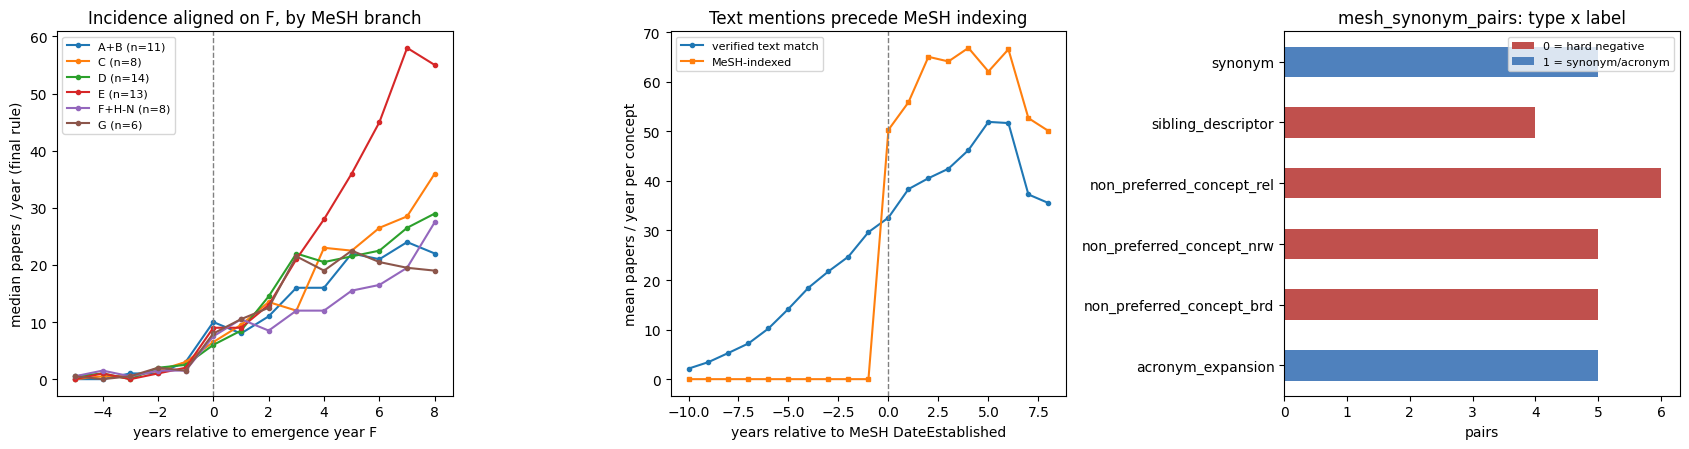

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (1) final-rule yearly counts aligned on emergence year F, median per branch group
ax = axes[0]
rel = np.arange(-5, 9)
for b, g in df.groupby("branch"):
    M = []
    for _, r in g.iterrows():
        idx = r["F"] - 2000 + rel
        M.append([r["final"][k] if 0 <= k < len(years) else np.nan for k in idx])
    ax.plot(rel, np.nanmedian(np.array(M), axis=0), marker="o", ms=3, label=f"{b} (n={len(g)})")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("years relative to emergence year F"); ax.set_ylabel("median papers / year (final rule)")
ax.set_title("Incidence aligned on F, by MeSH branch"); ax.legend(fontsize=8)

# (2) text-match vs MeSH-indexed counts relative to the year the descriptor was established
#     (mean over concepts that have data at that offset; late descriptors have no years after 2024)
ax = axes[1]
rel2 = np.arange(-10, 9)
T, Mh = [], []
for _, r in df.iterrows():
    idx = r["year_est"] - 2000 + rel2
    T.append([r["text"][k] if 0 <= k < len(years) else np.nan for k in idx])
    Mh.append([r["mesh"][k] if 0 <= k < len(years) else np.nan for k in idx])
ax.plot(rel2, np.nanmean(T, axis=0), marker="o", ms=3, label="verified text match")
ax.plot(rel2, np.nanmean(Mh, axis=0), marker="s", ms=3, label="MeSH-indexed")
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set_xlabel("years relative to MeSH DateEstablished"); ax.set_ylabel("mean papers / year per concept")
ax.set_title("Text mentions precede MeSH indexing"); ax.legend(fontsize=8)

# (3) synonym-pair label mix
ax = axes[2]
ct = pd.crosstab(pdf["metadata_pair_type"], pdf["output"]).reindex(columns=["0", "1"], fill_value=0)
ct.plot(kind="barh", stacked=True, ax=ax, color=["#c0504d", "#4f81bd"])
ax.set_xlabel("pairs"); ax.set_ylabel(""); ax.set_title("mesh_synonym_pairs: type x label")
ax.legend(["0 = hard negative", "1 = synonym/acronym"], fontsize=8)

plt.tight_layout(); plt.show()